libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


In [ ]:
data = load_iris()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
print(df.head())

X = df.drop('target', axis=1)
y = df['target']


   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  


train-test split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#Train Random forest model
model = RandomForestClassifier(
    n_estimators=100,     # number of trees
    max_depth=3,
    random_state=42
)
model.fit(X_train, y_train)

#Test the model
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


             Feature  Importance
2  petal length (cm)    0.452175
3   petal width (cm)    0.431695
0  sepal length (cm)    0.106226
1   sepal width (cm)    0.009903


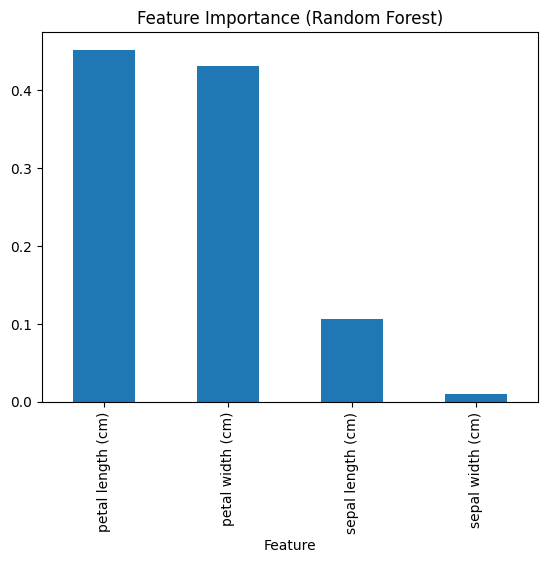

In [ ]:
#feature imporance
importance = model.feature_importances_
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print(feature_importance)

#visualizing the feature importance
feature_importance.plot(
    x='Feature', y='Importance', kind='bar', legend=False
)
plt.title("Feature Importance (Random Forest)")
plt.show()

visualizing single tree for interpretation

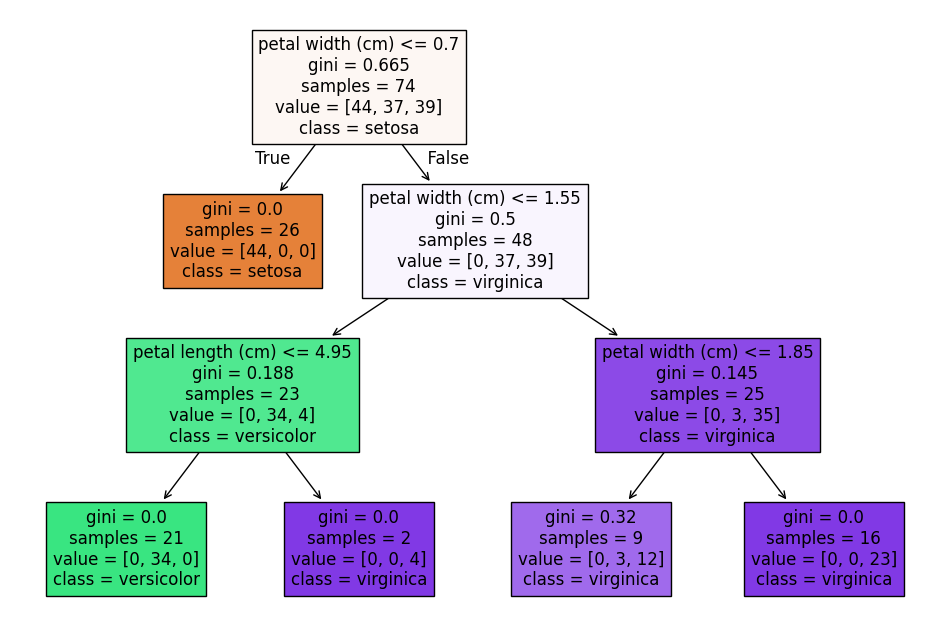

In [ ]:
from sklearn.tree import plot_tree

plt.figure(figsize=(12,8))
plot_tree(
    model.estimators_[0],   # first tree in forest
    feature_names=X.columns,
    class_names=data.target_names,
    filled=True
)
plt.show()
